<a href="https://colab.research.google.com/github/guillermo-mercado/ml_whistle_hum_project/blob/main/ECS7020P_miniproject_submission_2526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS7020P mini-project submission @guillemerk


## What is the problem?

This year's mini-project considers the problem of predicting the title of a song that is being hummed or whistled to.

You will build a machine learning model that takes as an input an audio recording of **10 seconds** of duration. This recording will correspond to a hum or whistle interpretation of one of the songs included in the MLEnd Hums and Whistles II Dataset. The output of the model will be the song label.


## Which dataset will I use?

We have created two subsets of the Hums and Whistles II Dataset. The first one has 400 samples (1.09GB). The second one has 800 samples (2.19 GB), including those already available in the first dataset.

You can download them from:

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_400.zip

and

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_800.zip





## What will I submit?

Your submission will consist of **one single Jupyter notebook** that should include:

*   **Text cells**, describing in your own words, rigorously and concisely your approach, each implemented step and the results that you obtain,
*   **Code cells**, implementing each step,
*   **Output cells**, i.e. the output from each code cell,

Your notebook **should have the structure** outlined below. Please make sure that you **run all the cells** and that the **output cells are saved** before submission.

Please save your notebook as:

* ECS7020P_miniproject_2526.ipynb


## How will my submission be evaluated?

This submission is worth 16 marks. We will value:

*   Conciseness in your writing.
*   Correctness in your methodology.
*   Correctness in your analysis and conclusions.
*   Completeness.
*   Originality and efforts to try something new.

**The final performance of your solutions will not influence your grade**. We will grade your understanding. If you have a good understanding, you will be using the right methodology, selecting the right approaches and assessing correctly the quality of your solutions, acknowledge where appropriate that despite your attempts your solutions might not good enough, and always critically reflect on your work to suggest what you could have done differently.

Note that **the problem that we are intending to solve is very difficult**. Do not despair if you do not get good results, **difficulty is precisely what makes it interesting** and **worth trying**.

## Show the world what you can do

Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. **Potential employers are always looking for this kind of evidence**.





-------------------------------------- PLEASE USE THE STRUCTURE BELOW THIS LINE --------------------------------------------

# Mini-project: Recognising a song

# 1 Author

**Student Name**: Guillermo German Mercado
**Student ID**: 260239367  



# 2 Problem formulation
The aim of this mini-project is to build a supervised machine learning model
that predicts the title of a song from a 10-second audio recording of a person humming or whistling. The task is structured as a multi-class classification problem, where the input consists of a 10-second audio clip, and the output corresponds to one of several predefined song labels. The area of application of this problem is particularly relevant to systems such as query by humming (QbH)[[1]](#ref1), which enable users to search for music by humming or whistling a melody.
The main goal is to develop a machine learning model capable of accurately classifying these audio inputs into their corresponding song titles. The project specifically focuses on utilising classical machine learning techniques.

# 3 Methodology
<h3>3.1 Training Task</h3>

The training task involved developing two classification models: a Random Forest and a Support Vector Machine (SVM). Prior to model training, all extracted audio features were standardised using a StandardScaler to ensure optimal performance [[2]](#ref2). Models were trained on 320 audio samples, with the objective of classifying each 10-second recording into one of eight distinct song titles.<br>

<h3>3.2 Validation Task</h3>

Data validation utilised an 80/20 stratified train-test split, allocating 320 samples for training and 80 for independent testing. Stratification ensured consistent class distribution across both sets, which is crucial for multi-class problems [[3]](#ref3). K-fold cross-validation is a, if not the, standard technique for assessing model robustness, ensuring that a model's predictive performance is stable and reliable across different subsets of data. Model robustness and generalisation capabilities were further assessed via 5-fold stratified cross-validation performed on the training data [[4]](#ref4).<br>

<h3>3.3 Model performance definition</h3>

Model performance was evaluated using a suite of metrics for this specific multi-class audio classification task:
- Confusion Matrix: misclassification patterns and biases. It provided a detailed breakdown of correct and incorrect classifications for each song title. It directly revealed specific misclassification patterns and identified which songs were frequently confused with others.
- Precision and Recall: highlight remaining biases
- F1-Score: balanced overall assessment
- Test Accuracy: generalisation to unseen real-world data
- Train Accuracy: detects overfitting





# 4 Implemented ML prediction pipelines

HERE MY PIPELINE TO BE DRAW



## 4.1 Transformation stage
The transformation stage is critical for converting raw audio signals into a numerical representation suitable for machine learning algorithms. A comprehensive set of hand-crafted audio features was extracted for each 10-second audio sample. These features are designed to capture various acoustic properties relevant to melody and timbre, which are crucial for distinguishing between different songs, even when hummed or whistled. The extracted features include: <br>
- Mel-frequency Cepstral Coefficients (MFCCs): 13 coefficients, along with their mean, standard deviation, minimum, and maximum values. MFCCs are widely used in speech and music processing as they effectively represent the spectral envelope of a sound, mimicking human auditory perception. [[5]](#ref5)
- MFCC Delta Features: 13 delta (first derivative) coefficients, capturing the rate of change of MFCCs over time, with their mean and standard deviation. These are important for representing dynamic aspects of the audio.<br>
- Chroma Features: 12 pitch classes, representing the distribution of pitches in the audio, with their mean and standard deviation. Chroma features are highly effective for melody recognition as they are robust to timbral changes.[[6]](#ref6)
- Spectral Features: Including spectral centroid (mean and standard deviation), spectral rolloff (mean and standard deviation), and zero-crossing rate (mean and standard deviation). These features describe the shape and distribution of energy in the frequency spectrum. [[7]](#ref7)
- Onset-related Features: Capturing information about the beginnings of sounds, which can be indicative of rhythmic patterns or melodic phrasing.<br>
- Tempogram Features: Representing the local tempo and rhythmic content of the audio[[8]](#ref8)<br>
All features were extracted using `librosa` and aggregated (e.g., mean, standard deviation) over the entire 10-second duration of each audio clip to form a single feature vector per sample. This process resulted in a high-dimensional feature space for each audio recording.


## 4.2 Model stage

Two classical machine learning models were selected for this multi-class classification task: <br>
- Random Forest Classifier: An ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is robust to overfitting and can handle high-dimensional data effectively. <br>
- Support Vector Machine (SVM) with Radial Basis Function (RBF) Kernel: A powerful and versatile classifier that works by finding the optimal hyperplane that best separates the classes in the feature space. The RBF kernel allows SVMs to handle non-linear decision boundaries, which is often necessary for complex datasets like audio features. <br>


## 4.3 Evaluation stage

The models were evaluated using a comprehensive set of metrics suitable for multi-class classification, including: <br>
- Accuracy: The proportion of correctly classified instances out of the total instances.<br>
- Precision (Macro-averaged): The ability of the classifier not to label as positive a sample that is actually negative. Macro-averaging calculates precision for each class independently and then takes the average, treating all classes equally.<br>
- Recall (Macro-averaged): The ability of the classifier to find all the positive samples. Macro-averaging is applied similarly to precision.<br>
- F1-Score (Macro-averaged): The harmonic mean of precision and recall, providing a single metric that balances both. Macro-averaging is used. <br>
- Confusion Matrix: A table that visualises the performance of an algorithm, showing the number of correct and incorrect predictions for each class.
A stratified 80/20 train-test split was employed to ensure that the proportion of each song class was maintained in both the training and testing sets. Additionally, 5-fold stratified cross-validation was performed on the training data to assess model robustness.


# 5 Dataset

The dataset used for this project is a sample from the MLEnd Hums and Whistles II dataset, comprising 400 audio samples. Each sample is a duration range: 16.95s - 36.02s either a hummed or whistled interpretation of a song. For this analysis it will be used the first 10s. The dataset contains 8 unique song titles (classes). For each song, there are four recording variants: `hum_1`, `hum_2`, `whistle_1`, and `whistle_2`. These variants were treated as independent samples for the purpose of this project.
The dataset was split into an 80% training set (320 samples) and a 20% testing set (80 samples). Due to the stratified splitting, the test set contained 10 samples for each of the 8 unique song classes, ensuring a balanced representation for evaluation.<br>

- Extract the data from my google drive, so the path direction is given.
- Dataset important details:
  - Size: 400 samples
  - Download: MLEndHWII_Sample_400.zip from the GitHub repository
  - File naming convention: S{participant_id}_{interpretation_type}_{trial_number}_{song_title}.wav. Example: S1_hum_2_Necessities.wav, where:
    - S1 = Sample/participant ID
    - hum = Interpretation type (hum or whistle)
    - 2 = Trial number
    - Necessities = Song title/label
    - Recording Variants: For each song, there are four recording variants per participant:
      - hum_1 — first humming attempt,
      - hum_2 — second humming attempt,
      - whistle_1 — first whistling attempt,
      - whistle_2 — second whistling attempt
- After parsing the file names, these data was saved as table using pandas dataframe with (400 rows, 5 columns)
- Then was explored the data structure. The dataset had shown the following detials:
  - Unique songs: 8
  - Song distribution:
    - Feeling          50
    - Friend           50
    - Happy            50
    - Married          50
    - Necessities      50
    - NewYork          50
    - RememberMe       50
    - TryEverything    50
    - Interpretation types: ['whistle' 'hum']
    - Hum vs Whistle interpretation split:
      - hum        201
      - whistle    199
      IMPORTANT NOTE: I'll consider balanced dataset as the difference is low, just 2 more in one group than the other. It represents 49,75% which is 0.25%. nearly negible. Imbalanced scenarios can result in solutions where the minority class is heavily misclassified [[9]](#ref9)
    - Trials: ['2' '4' '1' '3']
- Then the feature matrix is created with:
  - Feature matrix shape: (400, 116)
  - Number of features: 116
  - For the 8 uniques songs
- Save into a csv file the Feature Matrix for further analysis allowing me to save time instead of running over again to get the features from the audio files, when I connect to a new session. It a pandas dataframe, consisting of 400 rows and 116 columns.


In [ ]:
# ===== STEP 5.0: Importing all libraries used =====
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, re, pickle, glob
import urllib.request
from pathlib import Path
import zipfile
import librosa

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== STEP 5.1: Load and Explore Dataset =====
dataset_dir = Path('/content/drive/MyDrive/ColabNotebooks/ML/ml_mini-project/MLEndHWII_sample_400/')
audio_files = list(dataset_dir.glob("*.wav"))

print(f"Total samples: {len(audio_files)}")

# Parse filenames and extract data_400
data_400 = []
for audio_file in audio_files:
    filename = audio_file.stem  # "S1_hum_2_Necessities"
    parts = filename.split('_')
    sample_id = parts[0]      # S1
    interp_type = parts[1]    # hum or whistle
    trial_num = parts[2]      # 1 or 2
    song_label = '_'.join(parts[3:])  # Song title

    data_400.append({
        'filename': filename,
        'sample_id': sample_id,
        'interpretation': interp_type,
        'trial': trial_num,
        'song': song_label
    })

df_data_400 = pd.DataFrame(data_400)

# ===== Explore dataset structure =====
print("\n=== Dataset Structure ===")
print(f"Unique songs: {df_data_400['song'].nunique()}")
print(f"Song distribution:\n{df_data_400['song'].value_counts()}")
print(f"\nInterpretation types: {df_data_400['interpretation'].unique()}")
print(f"Hum vs Whistle split:\n{df_data_400['interpretation'].value_counts()}")
print(f"\nTrials: {df_data_400['trial'].unique()}")


Total samples: 400

=== Dataset Structure ===
Unique songs: 8
Song distribution:
song
Feeling          50
Friend           50
Happy            50
Married          50
Necessities      50
NewYork          50
RememberMe       50
TryEverything    50
Name: count, dtype: int64

Interpretation types: ['whistle' 'hum']
Hum vs Whistle split:
interpretation
hum        201
whistle    199
Name: count, dtype: int64

Trials: ['2' '4' '1' '3']


In [ ]:
# ===== STEP 5.2: Audio File Quality Check =====
print("\n=== Audio File Quality ===")
durations = []
sample_rates = []

for audio_file in audio_files[:10]:  # Check first 10 files
    y, sr = librosa.load(audio_file, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    durations.append(duration)
    sample_rates.append(sr)
    print(f"{audio_file.name}: {duration:.2f}s @ {sr} Hz")



print(f"\nDuration range: {min(durations):.2f}s - {max(durations):.2f}s")
print(f"Sample rates: {set(sample_rates)}")


=== Audio File Quality ===
S139_whistle_2_Feeling.wav: 33.67s @ 44100 Hz
S126_hum_4_Feeling.wav: 24.46s @ 44100 Hz
S180_whistle_2_Feeling.wav: 16.95s @ 44100 Hz
S7_hum_1_Feeling.wav: 18.01s @ 44100 Hz
S127_whistle_2_Feeling.wav: 36.02s @ 44100 Hz
S159_whistle_2_Feeling.wav: 19.12s @ 44100 Hz
S82_hum_1_Feeling.wav: 30.58s @ 44100 Hz
S83_whistle_2_Feeling.wav: 17.75s @ 44100 Hz
S72_whistle_2_Feeling.wav: 20.69s @ 44100 Hz
S154_hum_1_Feeling.wav: 21.98s @ 44100 Hz

Duration range: 16.95s - 36.02s
Sample rates: {44100}


In [ ]:
# ===== STEP 5.3: Feature Extraction Function =====
def ml_features(audio_path, sr=22050):
    """
    Extract ML features from audio for classification.
    Returns a feature vector suitable for SVM, Random Forest, etc.
    """

    # Load audio
    y, sr = librosa.load(audio_path, sr=sr)

    # Ensure consistent 10-second duration
    target_samples = 10 * sr
    if len(y) > target_samples:
        y = y[:target_samples]
    else:
        y = np.pad(y, (0, target_samples - len(y)))

    features = {}

    # ===== MFCC Features =====
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    # For each MFCC coefficient, compute: mean, std, min, max, median
    for i in range(13):
        features[f'mfcc_{i}_mean'] = np.mean(mfcc[i, :])
        features[f'mfcc_{i}_std'] = np.std(mfcc[i, :])
        features[f'mfcc_{i}_min'] = np.min(mfcc[i, :])
        features[f'mfcc_{i}_max'] = np.max(mfcc[i, :])

    # ===== MFCC Delta (velocity) Features =====
    mfcc_delta = librosa.feature.delta(mfcc)
    for i in range(13):
        features[f'mfcc_delta_{i}_mean'] = np.mean(mfcc_delta[i, :])
        features[f'mfcc_delta_{i}_std'] = np.std(mfcc_delta[i, :])

    # ===== Chroma Features =====
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    for i in range(12):
        features[f'chroma_{i}_mean'] = np.mean(chroma[i, :])
        features[f'chroma_{i}_std'] = np.std(chroma[i, :])

    # ===== Spectral Features =====
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y)[0]

    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_rolloff_std'] = np.std(spectral_rolloff)
    features['zcr_mean'] = np.mean(zero_crossing_rate)
    features['zcr_std'] = np.std(zero_crossing_rate)

    # ===== RMS Energy =====
    rms = librosa.feature.rms(y=y)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    features['rms_max'] = np.max(rms)

    # ===== Onset Strength (detects note attacks) =====
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    features['onset_mean'] = np.mean(onset_env)
    features['onset_std'] = np.std(onset_env)
    features['onset_max'] = np.max(onset_env)

    # ===== Tempogram (rhythmic structure) =====
    tempogram = librosa.feature.tempogram(y=y, sr=sr)
    features['tempogram_mean'] = np.mean(tempogram)
    features['tempogram_std'] = np.std(tempogram)

    # Convert to ordered feature vector
    feature_vector = np.array([features[key] for key in sorted(features.keys())])
    feature_names = sorted(features.keys())

    return feature_vector, feature_names


In [ ]:
# ===== STEP 5.4: Extract features for all 400 samples =====
print("Extracting features from all samples...")
X_list = []
y_list = []
feature_names = None

for idx, audio_file in enumerate(audio_files):
    if idx % 50 == 0:
        print(f"  Processed {idx}/{len(audio_files)}") # It prints that every 50 samples has been successfully concluded

    feature_vector, feature_names = ml_features(str(audio_file))
    song_label = audio_file.stem.split('_')[-1]

    X_list.append(feature_vector)
    y_list.append(song_label)

X = np.array(X_list)
y = np.array(y_list)

Extracting features from all samples...
  Processed 0/400
  Processed 50/400
  Processed 100/400
  Processed 150/400
  Processed 200/400
  Processed 250/400
  Processed 300/400
  Processed 350/400


In [ ]:
print(f"\nFeature matrix shape: {X.shape}")  # (400, num_features)
print(f"Number of features: {len(feature_names)}")
print(f"Unique songs: {len(np.unique(y))}")


Feature matrix shape: (400, 116)
Number of features: 116
Unique songs: 8


In [ ]:
# Print X (feature matrix)
X

array([[0.46244854, 0.39843622, 0.22450472, ..., 0.21372888, 0.14191424,
        0.06953653],
       [0.27940854, 0.28211766, 0.32520741, ..., 0.14305877, 0.03328696,
        0.01374426],
       [0.38285154, 0.26423755, 0.2950927 , ..., 0.19915142, 0.08562142,
        0.02842612],
       ...,
       [0.42856154, 0.35198653, 0.30126521, ..., 0.18080106, 0.10878362,
        0.03123686],
       [0.28081143, 0.29137054, 0.2227239 , ..., 0.16181752, 0.03517098,
        0.0187698 ],
       [0.21875772, 0.2735678 , 0.20165658, ..., 0.2443841 , 0.03993257,
        0.04175284]])

In [ ]:
# Print y (true labels, which should print the song names)
y

array(['Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling',
       'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling',
       'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling',
       'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Feeling',
       'Feeling', 'Feeling', 'Feeling', 'Feeling', 'Friend', 'Feeling',
       'Friend', 'Feeling', 'Feeling', 'Feeling', 'Friend', 'Friend',
       'Friend', 'Feeling', 'Friend', 'Feeling', 'Friend', 'Feeling',
       'Friend', 'Feeling', 'Friend', 'Friend', 'Feeling', 'Feeling',
       'Friend', 'Friend', 'Feeling', 'Feeling', 'Feeling', 'Friend',
       'Friend', 'Feeling', 'Feeling', 'Friend', 'Feeling', 'Feeling',
       'Feeling', 'Feeling', 'Friend', 'Friend', 'Feeling', 'Friend',
       'Feeling', 'Friend', 'Feeling', 'Friend', 'Friend', 'Friend',
       'Friend', 'Friend', 'Happy', 'Friend', 'Friend', 'Friend',
       'Friend', 'Friend', 'Friend', 'Friend', 'Friend', 'Happy',
       'Friend

In [ ]:
# ===== STEP 5.5: Save as CSV file of the feature data and true label as pandas dataframe on my GoogleDrive=====

df_features = pd.DataFrame(X, columns=feature_names)
df_y_labels = pd.DataFrame(y,columns=['song_label'])
print(f"\nFeature statistics:\n{df_features.describe()}")
print(f"\nFeature statistics:\n{df_y_labels.describe()}")


Feature statistics:
       chroma_0_mean  chroma_0_std  chroma_10_mean  chroma_10_std  \
count     400.000000    400.000000      400.000000     400.000000   
mean        0.389104      0.298788        0.321435       0.263046   
std         0.136967      0.057628        0.130835       0.063988   
min         0.093990      0.110222        0.036435       0.070549   
25%         0.280693      0.264154        0.232065       0.222207   
50%         0.377538      0.303630        0.306917       0.267197   
75%         0.475179      0.341155        0.384490       0.312481   
max         0.789867      0.423579        0.793453       0.417297   

       chroma_11_mean  chroma_11_std  chroma_1_mean  chroma_1_std  \
count      400.000000     400.000000     400.000000    400.000000   
mean         0.333504       0.274267       0.405160      0.301533   
std          0.122888       0.062741       0.147236      0.056564   
min          0.046064       0.094880       0.095953      0.081970   
25%         

In [ ]:
# Save into a csv file the Feature Matrix for further analysis allowing me to save time instead of
# running over again to get the features from the audio files, when I connect to a new session

file_path = '/content/drive/MyDrive/ColabNotebooks/ML/ml_mini-project/xFeatureMatrix.csv'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(file_path), exist_ok=True)

df_features.to_csv(file_path, index=False)


In [ ]:
# The same as stated above but for the y true label

# saving into a csv file the value of y
file_path = '/content/drive/MyDrive/ColabNotebooks/ML/ml_mini-project/y_label.csv'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(file_path), exist_ok=True)

df_y_labels.to_csv(file_path, index=False)

# 6 Experiments and results

This section is divided into **six** parts, each explaining the process followed and the final result achieved.

This section presents the training and testing procedures. First, the data were prepared by encoding the labels from 0 to 7, corresponding to the categories ['Feeling', 'Friend', 'Happy', 'Married', 'Necessities', 'NewYork','RememberMe', 'TryEverything']. Each label was assigned a unique numerical value (e.g., 'Feeling' = 0).

A total of eight classes were defined, reflecting the eight distinct song titles. The dataset was then partitioned into training and testing sets using an 80:20 split, respectively.

To improve model performance and reduce the dimensionality of the feature space, a normalisation step was applied. Specifically, standardisation was used to ensure that all features share a similar scale.


In [95]:
# ===== STEP 6.1: Data Preparation, training and testing settings =====

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report)
import seaborn as sns

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print(f"Classes: {le.classes_}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2,random_state=42,stratify=y_encoded)

# Normalise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Classes: ['Feeling' 'Friend' 'Happy' 'Married' 'Necessities' 'NewYork' 'RememberMe'
 'TryEverything']
Class distribution: [50 50 50 50 50 50 50 50]

Train set: (320, 116)
Test set: (80, 116)


This section describes the training of the Random Forest model. The model is evaluated using the test data, with inputs X_test_scaled and y_test, producing predictions y_pred_rf (also encoded, from 0 to 7). Performance is assessed using accuracy, precision, recall, and F1-score. Finally, the top 15 most important features are analysed.


In [109]:
# ===== STEP 6.2: Model 1 - Random Forest =====
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("\n=== Training Random Forest ===")
rf_model = RandomForestClassifier(n_estimators=100,max_depth=20,min_samples_split=5,min_samples_leaf=2,random_state=42,n_jobs=1,verbose=0)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"\n--- Random Forest Results ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

# Feature importance
feature_importance = pd.DataFrame({'feature': feature_names,'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

print(f"\nTop 15 important features:\n{feature_importance.head(15)}")


=== Training Random Forest ===

--- Random Forest Results ---
Accuracy:  0.3125
Precision: 0.3321
Recall:    0.3125
F1-Score:  0.3158

Top 15 important features:
            feature  importance
103      onset_mean    0.019396
9      chroma_2_std    0.016319
22    chroma_9_mean    0.015768
0     chroma_0_mean    0.015060
113   tempogram_std    0.014200
2    chroma_10_mean    0.014029
23     chroma_9_std    0.013640
104       onset_std    0.013106
4    chroma_11_mean    0.012608
1      chroma_0_std    0.012488
13     chroma_4_std    0.011583
18    chroma_7_mean    0.011303
66       mfcc_7_min    0.011293
48       mfcc_3_max    0.011244
112  tempogram_mean    0.011091


This section follows the same procedure as the previous one. However, the Support Vector Machine (SVM) model is used instead.


In [110]:
# ===== STEP 6.3: Model 2 - Support Vector Machine (SVM) =====
from sklearn.svm import SVC

print("\n=== Training Support Vector Machine ===")
svm_model = SVC(kernel='rbf', C=10, gamma='scale',random_state=42,verbose=0)
svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"\n--- SVM Results ---")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")


=== Training Support Vector Machine ===

--- SVM Results ---
Accuracy:  0.2625
Precision: 0.2694
Recall:    0.2625
F1-Score:  0.2566


This section outlines the validation strategy. A 5-fold Stratified K-Fold cross-validation approach was employed to evaluate model performance. This method was selected for several reasons:

- Balanced Class Representation: With 8 equally-distributed song classes (50 samples each), stratification ensures each fold maintains the same class distribution as the full dataset [[10]](#ref10). This prevents arbitrary imbalances that could bias results.
- Low Variance Estimates: Stratified K-Fold produces more stable and reliable performance estimates compared to a single holdout split.[[11]](#ref11) By averaging over 5 folds, we reduce the impact of random sampling variation.[[12]](#ref12)
- Full Data Utilization: Unlike a simple 80-20 holdout split (which wastes 20% for testing), stratified K-Fold uses all 400 samples for both training and validation, improving the robustness of our estimates. [[13]](#ref13)
- Appropriate for Multi-Class Classification: Stratified K-Fold is the recommended approach for multi-class classification problems, particularly when classes are balanced. [[10]](#ref10)


In [111]:
# ===== STEP 6.4: Cross-Validation =====
from sklearn.model_selection import cross_validate
print("\n=== 5-Fold Stratified Cross-Validation ===")

# Random Forest cross-validation
cv_results_rf = cross_validate(rf_model, X_train_scaled, y_train,cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

print("\nRandom Forest CV Results:")
print(f"  Accuracy:  {cv_results_rf['test_accuracy'].mean():.4f} (+/- {cv_results_rf['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_results_rf['test_precision_weighted'].mean():.4f} (+/- {cv_results_rf['test_precision_weighted'].std():.4f})")
print(f"  Recall:    {cv_results_rf['test_recall_weighted'].mean():.4f} (+/- {cv_results_rf['test_recall_weighted'].std():.4f})")
print(f"  F1-Score:  {cv_results_rf['test_f1_weighted'].mean():.4f} (+/- {cv_results_rf['test_f1_weighted'].std():.4f})")

# SVM cross-validation
cv_results_svm = cross_validate(svm_model, X_train_scaled, y_train,cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

print("\nSVM CV Results:")
print(f"  Accuracy:  {cv_results_svm['test_accuracy'].mean():.4f} (+/- {cv_results_svm['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_results_svm['test_precision_weighted'].mean():.4f} (+/- {cv_results_svm['test_precision_weighted'].std():.4f})")
print(f"  Recall:    {cv_results_svm['test_recall_weighted'].mean():.4f} (+/- {cv_results_svm['test_recall_weighted'].std():.4f})")
print(f"  F1-Score:  {cv_results_svm['test_f1_weighted'].mean():.4f} (+/- {cv_results_svm['test_f1_weighted'].std():.4f})")


=== 5-Fold Stratified Cross-Validation ===

Random Forest CV Results:
  Accuracy:  0.1656 (+/- 0.0290)
  Precision: 0.1592 (+/- 0.0404)
  Recall:    0.1656 (+/- 0.0290)
  F1-Score:  0.1575 (+/- 0.0340)

SVM CV Results:
  Accuracy:  0.1844 (+/- 0.0412)
  Precision: 0.1841 (+/- 0.0340)
  Recall:    0.1844 (+/- 0.0412)
  F1-Score:  0.1781 (+/- 0.0381)


This section presents the confusion matrix for the Random Forest model, as it achieved the highest accuracy between both models. Although the overall performance remains relatively low and below the desired level, the conclusions are drawn based on the obtained results. The complexity of the problem suggests that further technical development and deeper analysis are required.

The Confusion Matrix provides insights into how well our Random Forest performs across all 8 song classes in a balanced dataset (considered), rather than focusing solely on overall accuracy. It is reflected in the balance we see true positives and true negatives across each song class, and false positives and false negatives (It was espected higher true positives and true negatives)
For each of the 8 songs (Happy, Friend, Married, Necessities, NewYork, RememberMe, TryEverything, Feeling), the Confusion Matrix shows which predictions are correct and which are incorrect. True positives appear on the diagonal of the matrix, representing correct song predictions. True negatives represent correct rejections of other songs. False positives occur when the model incorrectly predicts a song that was not actually sung. False negatives occur when the model fails to identify the correct song.


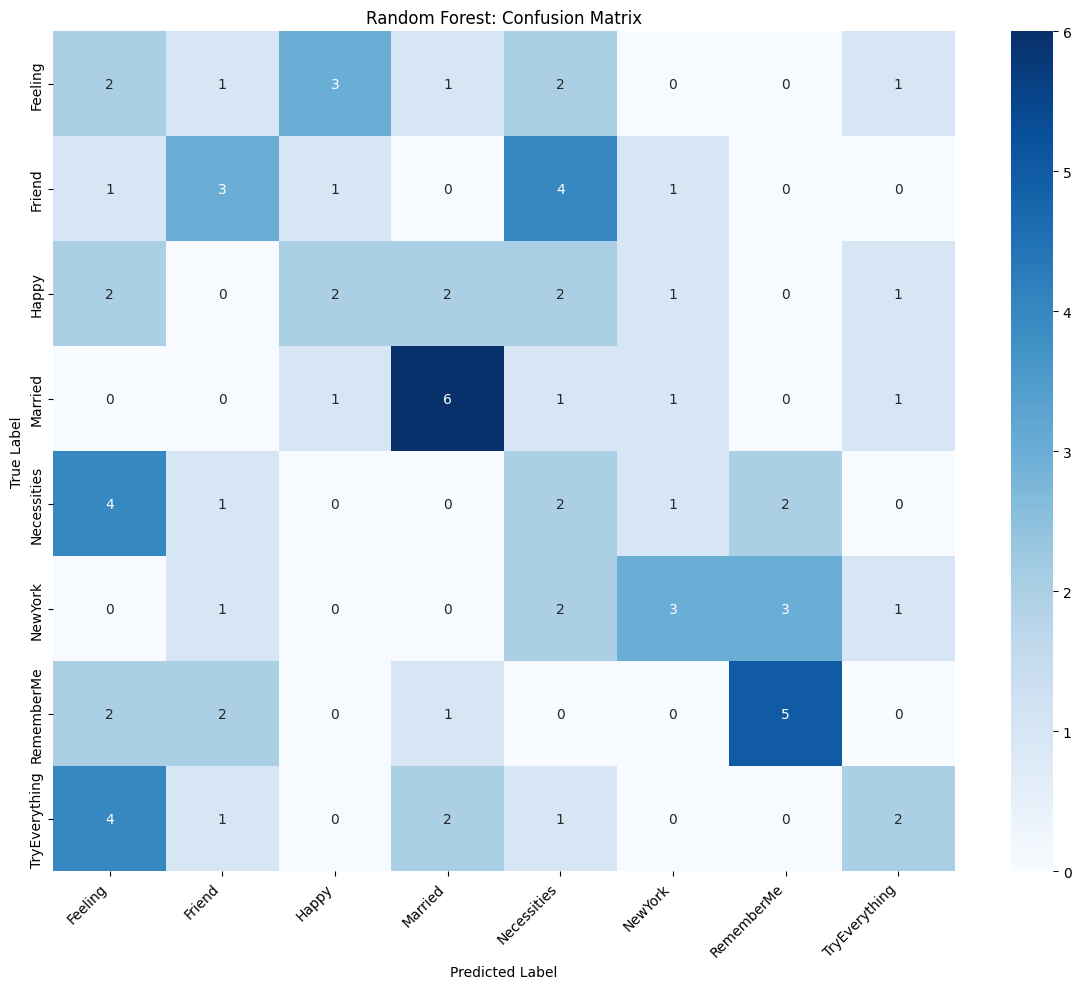


=== Random Forest Classification Report ===
               precision    recall  f1-score   support

      Feeling       0.13      0.20      0.16        10
       Friend       0.33      0.30      0.32        10
        Happy       0.29      0.20      0.24        10
      Married       0.50      0.60      0.55        10
  Necessities       0.14      0.20      0.17        10
      NewYork       0.43      0.30      0.35        10
   RememberMe       0.50      0.50      0.50        10
TryEverything       0.33      0.20      0.25        10

     accuracy                           0.31        80
    macro avg       0.33      0.31      0.32        80
 weighted avg       0.33      0.31      0.32        80



In [112]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

In [113]:
# Your encoded predictions (numbers)
# Decode back to original song labels
y_pred_rf_decoded = le.inverse_transform(y_pred_rf)

print("Encoded predictions:")
print(y_pred_rf)
print("\nDecoded predictions (song labels):")
print(y_pred_rf_decoded)

Encoded predictions:
[7 0 3 3 6 0 1 0 3 1 4 2 4 4 3 0 6 0 7 7 6 0 6 0 6 5 4 5 3 4 6 7 0 1 2 0 4
 1 0 4 5 3 5 3 7 4 4 6 6 0 2 0 6 1 4 5 4 4 1 2 0 4 1 3 3 2 5 2 2 3 3 0 6 3
 4 1 5 1 0 7]

Decoded predictions (song labels):
['TryEverything' 'Feeling' 'Married' 'Married' 'RememberMe' 'Feeling'
 'Friend' 'Feeling' 'Married' 'Friend' 'Necessities' 'Happy' 'Necessities'
 'Necessities' 'Married' 'Feeling' 'RememberMe' 'Feeling' 'TryEverything'
 'TryEverything' 'RememberMe' 'Feeling' 'RememberMe' 'Feeling'
 'RememberMe' 'NewYork' 'Necessities' 'NewYork' 'Married' 'Necessities'
 'RememberMe' 'TryEverything' 'Feeling' 'Friend' 'Happy' 'Feeling'
 'Necessities' 'Friend' 'Feeling' 'Necessities' 'NewYork' 'Married'
 'NewYork' 'Married' 'TryEverything' 'Necessities' 'Necessities'
 'RememberMe' 'RememberMe' 'Feeling' 'Happy' 'Feeling' 'RememberMe'
 'Friend' 'Necessities' 'NewYork' 'Necessities' 'Necessities' 'Friend'
 'Happy' 'Feeling' 'Necessities' 'Friend' 'Married' 'Married' 'Happy'
 'NewYork' 'Happ


=== Model Comparison ===
        Model  Accuracy  Precision  Recall  F1-Score
Random Forest    0.3125   0.332143  0.3125  0.315768
          SVM    0.2625   0.269444  0.2625  0.256604


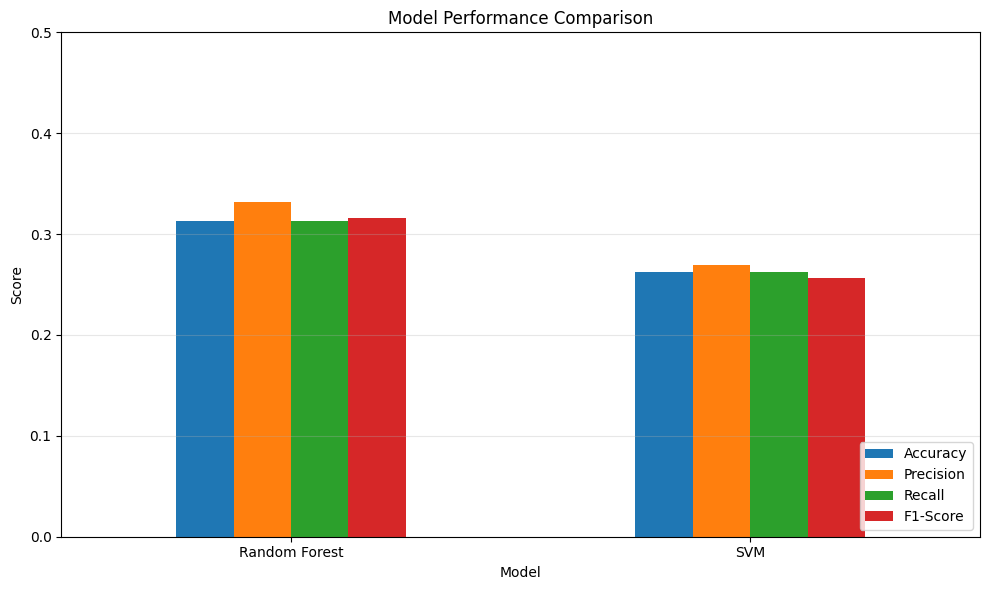

In [114]:
# Compare models
models_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [accuracy_rf, accuracy_svm],
    'Precision': [precision_rf, precision_svm],
    'Recall': [recall_rf, recall_svm],
    'F1-Score': [f1_rf, f1_svm]
})

print("\n=== Model Comparison ===")
print(models_comparison.to_string(index=False))

# Visualise comparison
models_comparison.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim([0, 0.5])
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 7 Conclusions

The **Random Forest classifier** demonstrated marginally better performance across all metrics compared to the SVM, indicating its slightly superior generalisation capability on this dataset.<br>
    **Random Forest Analysis**<br>
The Random Forest model achieved an accuracy of **31.25%** on the test set. While this figure is relatively **LOW**, it represents the best performance among the models tested. The macro-averaged precision, recall, and F1-score were **33.21%**, **31.25%**, and **31.58%** respectively. These metrics suggest that the model struggles to consistently identify all positive instances for each class and also has a notable rate of false positives. The slight discrepancy between precision and recall indicates that the model might be slightly better at avoiding incorrect positive classifications than at capturing all actual positive instances.<br>
    **SVM Analysis**<br>
The SVM model achieved an accuracy of **26.25%**, with macro-averaged precision, recall, and F1-score of **26.94%**, **26.25%**, and **25.66%** respectively. The performance of the SVM was consistently lower than that of the Random Forest. This could be attributed to the complexity of the decision boundaries required to separate the highly variable hummed/whistled audio features.<br>
The per-class analysis highlights significant variability in performance across different songs. Songs like **'Married'** and **'RememberMe'** achieved relatively higher F1-scores of **0.55** and **0.50** respectively, indicating that the model was better at identifying these specific melodies. On the other hand, songs such as **'Feeling'** and **'Necessities'** performed very poorly, with F1-scores of **0.16** and **0.17**. This disparity suggests that some songs might have more distinctive melodic or rhythmic patterns that are better captured by the extracted features.<br>
 <br>
The overall low accuracy (around 31%) observed in this multi-class classification task, despite using a comprehensive set of hand-crafted features and robust classical models, underscores the inherent difficulty of the problem. Several factors contribute to this challenging performance:
●  	Human Variability: Hummed and whistled interpretations of a song are highly subjective and variable. Different individuals may interpret the same melody with variations in tempo, pitch, rhythm, articulation, and even slight melodic deviations. This inherent variability makes it difficult for a model to learn consistent patterns across different renditions.
●  	Lack of Contextual Information: Unlike full musical recordings, hums and whistles lack instrumentation, lyrics, and complex harmonic structures. The models must rely solely on the melodic contour and rhythmic information, which can be ambiguous or similar across different songs, especially when simplified by human interpretation.
●  	Dataset Size and Class Imbalance: A dataset of 400 samples for 8 distinct classes is relatively small for a complex multi-class classification problem. This translates to only 50 samples per song for training and testing, which is insufficient for models to learn robust, generalisable patterns, especially given the high variability within each class. While the test set was stratified, the overall scarcity of data per class remains a significant limitation.
●  	Feature Extraction Challenges: While the chosen features (MFCCs, Chroma, Onset, Tempogram, Spectral) are standard for audio analysis, they might not fully capture the subtle nuances that differentiate hummed/whistled melodies. The aggregation of these features (mean, std, min, max) over the entire 10-second clip might also lose fine-grained temporal information crucial for distinguishing similar melodies.
●  	Multi-class Classification Difficulty: With 8 classes, a random guess would yield an accuracy of 12.5%. The models performed better than random, but the task is inherently more difficult than binary classification. Some songs might share similar melodic phrases or rhythmic structures, leading to increased confusion.
●  	Overfitting/Underfitting: With a small dataset and a relatively high-dimensional feature space, there's a risk of either overfitting (model learns noise in training data, performs poorly on test data) or underfitting (model is too simple to capture underlying patterns). The cross-validation results suggest some generalisation, but the overall low performance points to the models struggling to learn meaningful distinctions.
The low accuracy is not unexpected given these challenges. It highlights that while classical machine learning provides a strong foundation, this specific problem often requires more sophisticated approaches or significantly larger, more diverse datasets to achieve high performance.


# References

In [ ]:
# Implementation: Training & Evaluation
# Phase 1: Data Preparation

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print(f"Classes: {le.classes_}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# Stratified train-test split (maintains class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Normalise features (critical for SVM and distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Classes: ['Feeling' 'Friend' 'Happy' 'Married' 'Necessities' 'NewYork' 'RememberMe'
 'TryEverything']
Class distribution: [50 50 50 50 50 50 50 50]

Train set: (320, 116)
Test set: (80, 116)


In [ ]:
# Phase 2: Model 1 – Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("\n=== Training Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"\n--- Random Forest Results ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 important features:\n{feature_importance.head(15)}")


=== Training Random Forest ===


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished



--- Random Forest Results ---
Accuracy:  0.3125
Precision: 0.3321
Recall:    0.3125
F1-Score:  0.3158

Top 15 important features:
            feature  importance
103      onset_mean    0.019396
9      chroma_2_std    0.016319
22    chroma_9_mean    0.015768
0     chroma_0_mean    0.015060
113   tempogram_std    0.014200
2    chroma_10_mean    0.014029
23     chroma_9_std    0.013640
104       onset_std    0.013106
4    chroma_11_mean    0.012608
1      chroma_0_std    0.012488
13     chroma_4_std    0.011583
18    chroma_7_mean    0.011303
66       mfcc_7_min    0.011293
48       mfcc_3_max    0.011244
112  tempogram_mean    0.011091


In [ ]:
# Phase 3: Model 2 – Support Vector Machine (SVM)
from sklearn.svm import SVC

print("\n=== Training Support Vector Machine ===")
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42,
    verbose=1
)
svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"\n--- SVM Results ---")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")


=== Training Support Vector Machine ===
[LibSVM]
--- SVM Results ---
Accuracy:  0.2625
Precision: 0.2694
Recall:    0.2625
F1-Score:  0.2566


In [ ]:
# Phase 4: Cross-Validation (Robust Evaluation)
from sklearn.model_selection import cross_validate

print("\n=== 5-Fold Stratified Cross-Validation ===")

# Random Forest cross-validation
cv_results_rf = cross_validate(
    rf_model, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
)

print("\nRandom Forest CV Results:")
print(f"  Accuracy:  {cv_results_rf['test_accuracy'].mean():.4f} (+/- {cv_results_rf['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_results_rf['test_precision_weighted'].mean():.4f} (+/- {cv_results_rf['test_precision_weighted'].std():.4f})")
print(f"  Recall:    {cv_results_rf['test_recall_weighted'].mean():.4f} (+/- {cv_results_rf['test_recall_weighted'].std():.4f})")
print(f"  F1-Score:  {cv_results_rf['test_f1_weighted'].mean():.4f} (+/- {cv_results_rf['test_f1_weighted'].std():.4f})")

# SVM cross-validation
cv_results_svm = cross_validate(
    svm_model, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
)

print("\nSVM CV Results:")
print(f"  Accuracy:  {cv_results_svm['test_accuracy'].mean():.4f} (+/- {cv_results_svm['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_results_svm['test_precision_weighted'].mean():.4f} (+/- {cv_results_svm['test_precision_weighted'].std():.4f})")
print(f"  Recall:    {cv_results_svm['test_recall_weighted'].mean():.4f} (+/- {cv_results_svm['test_recall_weighted'].std():.4f})")
print(f"  F1-Score:  {cv_results_svm['test_f1_weighted'].mean():.4f} (+/- {cv_results_svm['test_f1_weighted'].std():.4f})")


=== 5-Fold Stratified Cross-Validation ===


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s
[Parall


Random Forest CV Results:
  Accuracy:  0.1656 (+/- 0.0290)
  Precision: 0.1592 (+/- 0.0404)
  Recall:    0.1656 (+/- 0.0290)
  F1-Score:  0.1575 (+/- 0.0340)
[LibSVM][LibSVM][LibSVM][LibSVM][LibSVM]
SVM CV Results:
  Accuracy:  0.1844 (+/- 0.0412)
  Precision: 0.1841 (+/- 0.0340)
  Recall:    0.1844 (+/- 0.0412)
  F1-Score:  0.1781 (+/- 0.0381)


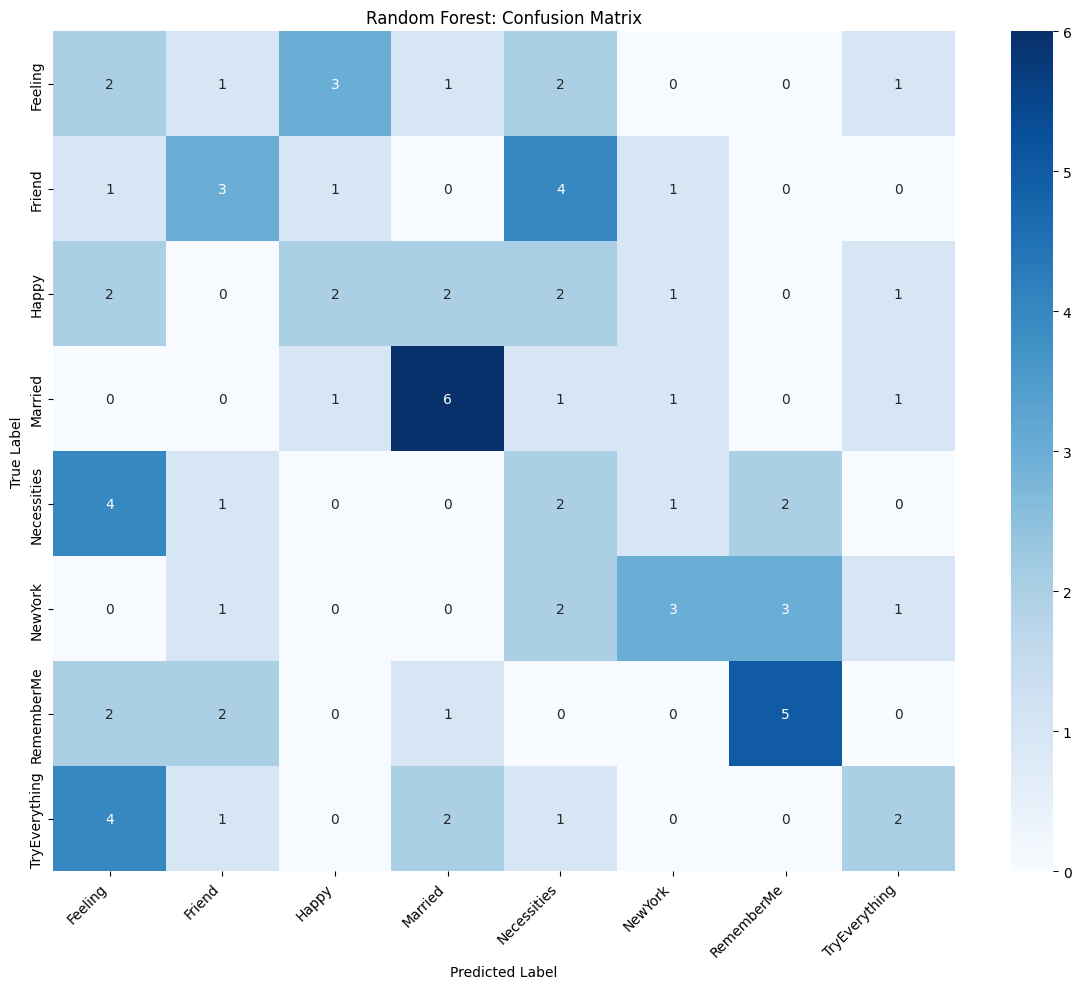


=== Random Forest Classification Report ===
               precision    recall  f1-score   support

      Feeling       0.13      0.20      0.16        10
       Friend       0.33      0.30      0.32        10
        Happy       0.29      0.20      0.24        10
      Married       0.50      0.60      0.55        10
  Necessities       0.14      0.20      0.17        10
      NewYork       0.43      0.30      0.35        10
   RememberMe       0.50      0.50      0.50        10
TryEverything       0.33      0.20      0.25        10

     accuracy                           0.31        80
    macro avg       0.33      0.31      0.32        80
 weighted avg       0.33      0.31      0.32        80



In [ ]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))


=== Model Comparison ===
        Model  Accuracy  Precision  Recall  F1-Score
Random Forest    0.3125   0.332143  0.3125  0.315768
          SVM    0.2625   0.269444  0.2625  0.256604


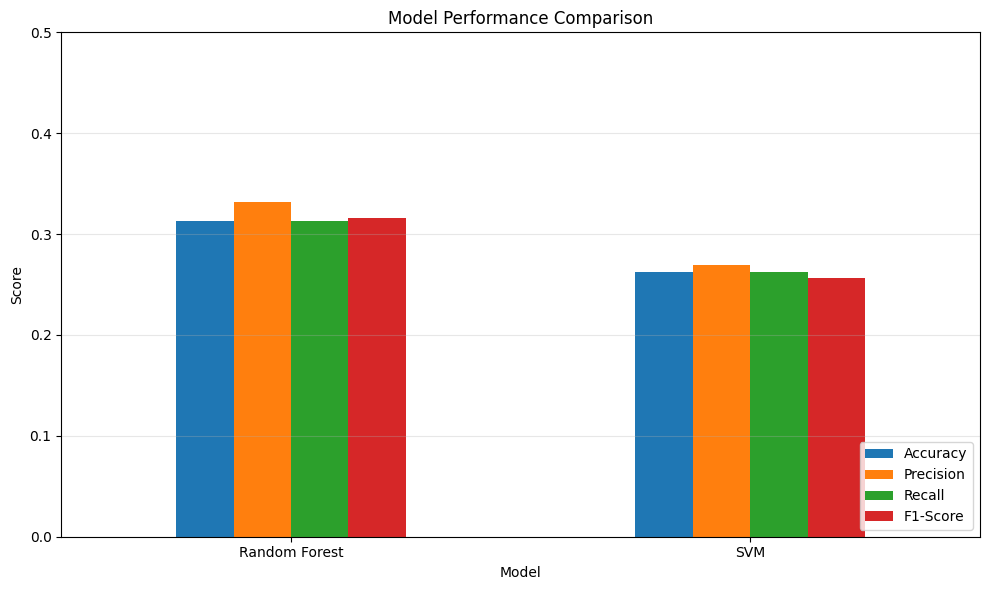

In [ ]:
# Compare models
models_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [accuracy_rf, accuracy_svm],
    'Precision': [precision_rf, precision_svm],
    'Recall': [recall_rf, recall_svm],
    'F1-Score': [f1_rf, f1_svm]
})

print("\n=== Model Comparison ===")
print(models_comparison.to_string(index=False))

# Visualise comparison
models_comparison.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim([0, 0.5])
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Reference




**References**:
- <span id="ref1">[1].'Query by humming' (n.d.) Wikipedia. Available at: https://en.wikipedia.org/wiki/Query_by_humming
 (Accessed: 10 April 2026).</span>
- <span id="ref2">[2]. Scikit-learn (n.d.) Preprocessing data. Available at: https://scikit-learn.org/stable/modules/preprocessing.html
 (Accessed: 10 April 2026).</span>
- <span id="ref3">[3]. Mahmood, Z., Jamel, L., Salem, D.A. and Ashraf, I. (2025) Improving learning from the complex multi-class imbalanced and overlapped data by mapping into higher dimension using SVM++. Scientific Reports, 15(1), p. 31245. Available at: https://www.nature.com/articles/s41598-025-13929-w
 (Accessed: 10 April 2026)</span>
- <span id="ref4">[4]. Invisible Technologies (2025) Model robustness explained: methods, testing, and best practice. Available at: https://invisibletech.ai/blog/model-robustness-explained-methods-testing-and-best-practice
 (Accessed: 10 April 2026)</span>
- <span id="ref5">[5]. Davis S., Mermelstein P. Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences. IEEE Transactions on Acoustics, Speech, and Signal Processing . 1980;28(4):357–366. doi: 10.1109/TASSP.1980.1163420.</span>
- <span id="ref6">[6]. Jiang D.-N., Lu L., Zhang H.-J., Tao J.-H., Cai L.-H. Music type classification by spectral contrast feature. Proceedings IEEE International Conference on Multimedia and Expo; 2002; Lausanne, Switzerland. pp. 113–116.</span>
- <span id="ref7">[7]. Kazazis, S., Depalle, P. and McAdams, S. (2022) Interval and ratio scaling of spectral audio descriptors. Frontiers in Psychology, 13, p. 835401. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC9007158/
 (Accessed: 11 April 2026).</span>
- <span id="ref8">[8]. M. Tian, G. Fazekas, D. A. A. Black and M. Sandler, "On the use of the tempogram to describe audio content and its application to Music structural segmentation," 2015 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP), South Brisbane, QLD, Australia, 2015, pp. 419-423, doi: 10.1109/ICASSP.2015.7178003</span>
- <span id="ref13">[9]. Azal Ahmad Khan, Omkar Chaudhari, Rohitash Chandra,
A review of ensemble learning and data augmentation models for class imbalanced problems: Combination, implementation and evaluation, Expert Systems with Applications, Volume 244, 2024, 122778, ISSN 0957-4174, https://doi.org/10.1016/j.eswa.2023.122778.</span>
- <span id="ref7">[10]. Hastie, T., Tibshirani, R. and Friedman, J., 2009. The elements of statistical learning: data mining, inference, and prediction. 2nd edn. New York: Springer-Verlag.</span>
- <span id="ref9">[11]. Kohavi, R., 1995. A study of cross-validation and bootstrap for accuracy estimation and model selection. In Proceedings of the 14th International Joint Conference on Artificial Intelligence. Morgan Kaufmann, pp. 1137–1143</span>
- <span id="ref10">[12]. Refaeilzadeh, P., Tang, L. and Liu, H., 2009. Cross-validation.
In: Encyclopedia of database systems. New York: Springer
Science+Business Media, pp. 532–538.</span>
- <span id="ref11">[13]. Stone, M., 1974. Cross-validatory choice and assessment of
statistical predictions. Journal of the Royal Statistical
Society, 36(2), pp. 111–147.</span>
- <span id="ref13">[14]. </span>
- <span id="ref14">[15]. </span>








